In [1]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Patch

from lameg.surf import create_surf_gifti
from lameg.viz import show_surface, color_map, rgbtoint
from lameg.util import get_bigbrain_layer_boundaries, load_meg_sensor_data, convert_native_to_fsaverage
from scipy.signal import correlate
import scipy.io as sio
import io
from PIL import Image
from base64 import b64decode
from scipy.io import savemat, loadmat

In [2]:
plt.rcParams.update({
    'font.size': 16,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

In [3]:
def align_to_peak(X, ref_idx=0):
    X = np.asarray(X)
    n_series, n_time = X.shape
    ref_peak = int(np.argmin(X[ref_idx]))
    peaks = np.argmin(X, axis=1).astype(int)
    lags = ref_peak - peaks                     # +lag -> shift right
    base = np.arange(n_time)
    align_idx = [np.clip(base - lag, 0, n_time - 1) for lag in lags]
    return lags, align_idx

In [4]:
vc_preproc_data_dir='/home/common/bonaiuto/cued_action_meg/derivatives/processed'
sp_preproc_data_dir='/home/common/bonaiuto/auditory_laminar/derivatives/processed/'

In [5]:
fsave_lh_coords, fsave_lh_faces = nib.freesurfer.io.read_geometry('/home/common/bonaiuto/cued_action_meg/derivatives/processed/fs/fsaverage/surf/lh.inflated')
fsave_lh = create_surf_gifti(fsave_lh_coords, fsave_lh_faces)
lh_curv_data = nib.freesurfer.read_morph_data('/home/common/bonaiuto/cued_action_meg/derivatives/processed/fs/fsaverage/surf/lh.curv')

In [6]:
win_sizes=[10, 25, 50]

In [7]:
motor_comps=['01_mf', '02_mefI']
all_prior_ts={
    comp: {
        win_size: [] for win_size in win_sizes
    } for comp in motor_comps
}
all_layer_F={
    comp: {
        win_size: [] for win_size in win_sizes
    } for comp in motor_comps
}
all_layer_F_diff={
    comp: {
        win_size: [] for win_size in win_sizes
    } for comp in motor_comps
}
aligned_prior_ts = {
    comp: {
        win_size: [] for win_size in win_sizes
    } for comp in motor_comps
}
aligned_layer_F = {
    comp: {
        win_size: [] for win_size in win_sizes
    } for comp in motor_comps
}
aligned_layer_F_diff = {
    comp: {
        win_size: [] for win_size in win_sizes
    } for comp in motor_comps
}
aligned_subjects_m_prior_ts = {
    comp: {
        win_size: [] for win_size in win_sizes
    } for comp in motor_comps
}
aligned_subjects_m_layer_F = {
    comp: {
        win_size: [] for win_size in win_sizes
    } for comp in motor_comps
}
aligned_subjects_m_layer_F_diff = {
    comp: {
        win_size: [] for win_size in win_sizes
    } for comp in motor_comps
}


In [8]:
polarity={
    '01_mf': {        
        'sub-001': [-1],
        'sub-002': [-1,-1,-1,-1],
        'sub-003': [-1,-1],
        'sub-004': [-1],
        'sub-005': [-1,-1,-1],
        'sub-006': [-1],
        'sub-007': [1,1,1,1],
        'sub-008': [1,1,1],
        'sub-104': [1],
        'sub-105': [1],
        'sub-114': [-1]
    },
    '02_mefI': {
       'sub-001': [-1],
        'sub-002': [-1,-1,-1,-1],
        'sub-003': [-1,-1,-1,-1],
        'sub-004': [-1,-1,-1,-1],
        'sub-005': [-1,-1,1,-1],
        'sub-006': [-1],
        'sub-007': [1,-1,1,-1],
        'sub-008': [-1,-1,-1],
        'sub-104': [-1],
        'sub-105': [-1],
        'sub-106': [-1],
        'sub-114': [-1]
    }
}

In [9]:
all_prior_ts

{'01_mf': {10: [], 25: [], 50: []}, '02_mefI': {10: [], 25: [], 50: []}}

In [10]:
time_lims=[-500, 500]
n_layers=11

for comp in motor_comps:
    for win_size in win_sizes:
        %env SUBJECTS_DIR=/home/common/bonaiuto/cued_action_meg/derivatives/processed/fs/
        subjects=[
            'sub-001',
            'sub-002',
            'sub-003',
            'sub-004',
            'sub-005',
            'sub-006',
            'sub-007',
            'sub-008'
        ]
        sessions={
            'sub-001': ['ses-01'],
            'sub-002': ['ses-03','ses-04','ses-05','ses-06'],
            'sub-003': ['ses-01','ses-03'],
            'sub-004': ['ses-01'],
            'sub-005': ['ses-01','ses-03','ses-04'],
            'sub-006': ['ses-03'],
            'sub-007': ['ses-01','ses-02','ses-03','ses-04'],
            'sub-008': ['ses-03','ses-04','ses-05']
        }
        
        subj_session_idx = {}

        if win_size!=25:
            out_dir=os.path.join(
                '/home/bonaiuto/laminar_erf/output/motor_epoch',
                comp, 
                'patch_size_5.00mm',
                f'win_size_{win_size}ms'
            )
        else:
            out_dir=os.path.join(
                '/home/bonaiuto/laminar_erf/output/motor_epoch',
                comp, 
                'patch_size_5.00mm'
            )

        overall_ses_idx = 0
        for subject in subjects:
            subj_session_idx[subject] = []

            for sess_idx, session in enumerate(sessions[subject]):
                session_polarity=polarity[comp][subject][sess_idx]
                out_fname = os.path.join(out_dir,f'results_{subject}_{session}.npz')
                if os.path.exists(out_fname):                    

                    subj_surf_dir=os.path.join(vc_preproc_data_dir,subject,'surf')
                    ds_pial = nib.load(os.path.join(subj_surf_dir, 'pial.ds.gii'))

                    data = np.load(out_fname, allow_pickle=True)
                    prior = data['prior']
                    prior_ts = data['prior_ts']*1000
                    ts_time_motor = data['ts_time']
                    Fs = data['Fs']
                    wois = data['wois']

                    woi_time=np.mean(wois,axis=-1)
                    t_idx=np.where((woi_time>=time_lims[0]) & (woi_time<=time_lims[1]))[0]
                    woi_win_motor=woi_time[t_idx]
                    Fs_win=Fs[:,t_idx]

                    ts_idx=np.where((ts_time_motor>=time_lims[0]) & (ts_time_motor<=time_lims[1]))[0]
                    prior_ts=prior_ts[ts_idx]
                    ts_time_motor=ts_time_motor[ts_idx]

                    surf_bb_bounds=n_layers*get_bigbrain_layer_boundaries(subject, subj_surf_dir, subj_coord=ds_pial.darrays[0].data[prior,:])

                    prior_ts = session_polarity*prior_ts            

                    layers=np.arange(n_layers)
                    layer1_idx=np.where((layers<surf_bb_bounds[0]))[0]
                    layer2_idx=np.where((layers>=surf_bb_bounds[0]) & (layers<surf_bb_bounds[1]))[0]
                    layer3_idx=np.where((layers>=surf_bb_bounds[1]) & (layers<surf_bb_bounds[2]))[0]
                    layer4_idx=np.where((layers>=surf_bb_bounds[2]) & (layers<surf_bb_bounds[3]))[0]
                    layer5_idx=np.where((layers>=surf_bb_bounds[3]) & (layers<surf_bb_bounds[4]))[0]
                    layer6_idx=np.where((layers>=surf_bb_bounds[4]))[0]

                    layer_F = np.vstack([
                        np.mean(Fs_win[layer1_idx,:],axis=0),
                        np.mean(Fs_win[layer2_idx,:],axis=0),
                        np.mean(Fs_win[layer3_idx,:],axis=0),
                        np.mean(Fs_win[layer4_idx,:],axis=0),
                        np.mean(Fs_win[layer5_idx,:],axis=0),
                        np.mean(Fs_win[layer6_idx,:],axis=0)
                    ])
                    layer_F_diff = np.zeros((layer_F.shape[0],layer_F.shape[1]))
                    for t in range(layer_F.shape[1]):
                        minF = np.nanmin(layer_F[:,t])
                        layer_F_diff[:,t] = layer_F[:,t]-minF

                    subj_session_idx[subject].append(overall_ses_idx)
                    
                    all_prior_ts[comp][win_size].append(prior_ts)
                    all_layer_F[comp][win_size].append(layer_F)
                    all_layer_F_diff[comp][win_size].append(layer_F_diff)
                    overall_ses_idx = overall_ses_idx+1
        
        %env SUBJECTS_DIR=/home/common/bonaiuto/auditory_laminar/derivatives/fs/
        subjects = [
            'sub-104',
            'sub-105',
            'sub-114'
        ]
        sessions = {
            'sub-104': ['ses-01'],
            'sub-105': ['ses-01'],
            'sub-114': ['ses-01']
        }        
        if comp=='02_mefI':
            subjects.append('sub-106')
            sessions['sub-106']=['ses-01']
        
        
        epo_type='btn_trial'

        if win_size!=25:
            out_dir=os.path.join(
                '/home/bonaiuto/auditory_laminar/output',
                epo_type,
                comp,
                'patch_size_5.00mm',
                f'win_size_{win_size}ms'
            )
        else:
            out_dir=os.path.join(
                '/home/bonaiuto/auditory_laminar/output',
                epo_type,
                comp,
                'patch_size_5.00mm'
            ) 

        for subject in subjects:
            subj_session_idx[subject] = []
            for sess_idx, session in enumerate(sessions[subject]):
                session_polarity=polarity[comp][subject][sess_idx]
                out_fname = os.path.join(out_dir,f'results_{subject}_{session}.npz')
                if os.path.exists(out_fname):
                    
                    subj_surf_dir=os.path.join(sp_preproc_data_dir,subject,'surf')
                    ds_pial = nib.load(os.path.join(subj_surf_dir, 'pial.ds.gii'))

                    data = np.load(out_fname, allow_pickle=True)
                    prior = data['prior']
                    prior_ts = data['prior_ts']*1000
                    ts_time_motor = data['ts_time']
                    Fs = data['Fs']
                    wois = data['wois']

                    woi_time=np.mean(wois,axis=-1)
                    t_idx=np.where((woi_time>=time_lims[0]) & (woi_time<=time_lims[1]))[0]
                    woi_win_motor=woi_time[t_idx]
                    Fs_win=Fs[:,t_idx]

                    ts_idx=np.where((ts_time_motor>=time_lims[0]) & (ts_time_motor<=time_lims[1]))[0]
                    prior_ts=prior_ts[ts_idx]
                    ts_time_motor=ts_time_motor[ts_idx]

                    surf_bb_bounds=n_layers*get_bigbrain_layer_boundaries(subject, subj_surf_dir, subj_coord=ds_pial.darrays[0].data[prior,:])

                    prior_ts = session_polarity*prior_ts

                    layers=np.arange(n_layers)
                    layer1_idx=np.where((layers<surf_bb_bounds[0]))[0]
                    layer2_idx=np.where((layers>=surf_bb_bounds[0]) & (layers<surf_bb_bounds[1]))[0]
                    layer3_idx=np.where((layers>=surf_bb_bounds[1]) & (layers<surf_bb_bounds[2]))[0]
                    layer4_idx=np.where((layers>=surf_bb_bounds[2]) & (layers<surf_bb_bounds[3]))[0]
                    layer5_idx=np.where((layers>=surf_bb_bounds[3]) & (layers<surf_bb_bounds[4]))[0]
                    layer6_idx=np.where((layers>=surf_bb_bounds[4]))[0]

                    layer_F = np.vstack([
                        np.mean(Fs_win[layer1_idx,:],axis=0),
                        np.mean(Fs_win[layer2_idx,:],axis=0),
                        np.mean(Fs_win[layer3_idx,:],axis=0),
                        np.mean(Fs_win[layer4_idx,:],axis=0),
                        np.mean(Fs_win[layer5_idx,:],axis=0),
                        np.mean(Fs_win[layer6_idx,:],axis=0)
                    ])
                    layer_F_diff = np.zeros((layer_F.shape[0],layer_F.shape[1]))
                    for t in range(layer_F.shape[1]):
                        minF = np.nanmin(layer_F[:,t])
                        layer_F_diff[:,t] = layer_F[:,t]-minF

                    subj_session_idx[subject].append(overall_ses_idx)
                    all_prior_ts[comp][win_size].append(prior_ts)
                    all_layer_F[comp][win_size].append(layer_F)
                    all_layer_F_diff[comp][win_size].append(layer_F_diff)
                    overall_ses_idx = overall_ses_idx+1
        
        all_prior_ts[comp][win_size]=np.array(all_prior_ts[comp][win_size])
        all_layer_F[comp][win_size]=np.array(all_layer_F[comp][win_size])
        all_layer_F_diff[comp][win_size]=np.array(all_layer_F_diff[comp][win_size])
        
        subjects=[
            'sub-001',
            'sub-002',
            'sub-003',
            'sub-004',
            'sub-005',
            'sub-006',
            'sub-007',
            'sub-008',
            'sub-104',
            'sub-105',
            'sub-114'
        ]
        sessions={
            'sub-001': ['ses-01'],
            'sub-002': ['ses-03','ses-04','ses-05','ses-06'],
            'sub-003': ['ses-01','ses-03'],
            'sub-004': ['ses-01'],
            'sub-005': ['ses-01','ses-03','ses-04'],
            'sub-006': ['ses-03'],
            'sub-007': ['ses-01','ses-02','ses-03','ses-04'],
            'sub-008': ['ses-03','ses-04','ses-05'],
            'sub-104': ['ses-01'],
            'sub-105': ['ses-01'],
            'sub-114': ['ses-01']
        }
        if comp=='02_mefI':
            subjects.append('sub-106')
            sessions['sub-106']=['ses-01']
        
        for s_idx in range(all_layer_F[comp][win_size].shape[0]):
            for l_idx in range(all_layer_F[comp][win_size].shape[1]):
                if np.any(np.isnan(all_layer_F[comp][win_size][s_idx,l_idx,:])):
                    prev_row = all_layer_F[comp][win_size][s_idx, l_idx - 1, :]
                    next_row = all_layer_F[comp][win_size][s_idx, l_idx + 1, :]
                    all_layer_F[comp][win_size][s_idx, l_idx, :] = 0.5 * (prev_row + next_row)

        lags, align_idx = align_to_peak(all_prior_ts[comp][win_size])


        for ss_idx in range(all_prior_ts[comp][win_size].shape[0]):
            aligned_idx = align_idx[ss_idx]

            aligned_prior_ts[comp][win_size].append(all_prior_ts[comp][win_size][ss_idx, aligned_idx])
            aligned_layer_F[comp][win_size].append(all_layer_F[comp][win_size][ss_idx, :, aligned_idx])
            aligned_layer_F_diff[comp][win_size].append(all_layer_F_diff[comp][win_size][ss_idx, :, aligned_idx])

        aligned_prior_ts[comp][win_size] = np.array(aligned_prior_ts[comp][win_size])
        aligned_layer_F[comp][win_size] = np.transpose(np.array(aligned_layer_F[comp][win_size]), (0, 2, 1))
        aligned_layer_F_diff[comp][win_size] = np.transpose(np.array(aligned_layer_F_diff[comp][win_size]), (0, 2, 1))
        
        for s_idx, subject in enumerate(subjects):
            sess_idx = subj_session_idx[subject]
            subj_m_prior_ts = np.mean(aligned_prior_ts[comp][win_size][sess_idx,:],axis=0)
            subj_m_layer_F = np.nanmean(aligned_layer_F[comp][win_size][sess_idx,:,:],axis=0)
            subj_m_layer_F_diff = np.nanmean(aligned_layer_F_diff[comp][win_size][sess_idx,:,:],axis=0)

            aligned_subjects_m_prior_ts[comp][win_size].append(subj_m_prior_ts)
            aligned_subjects_m_layer_F[comp][win_size].append(subj_m_layer_F)
            aligned_subjects_m_layer_F_diff[comp][win_size].append(subj_m_layer_F_diff)

        aligned_subjects_m_prior_ts[comp][win_size] = np.array(aligned_subjects_m_prior_ts[comp][win_size])
        aligned_subjects_m_layer_F[comp][win_size] = np.array(aligned_subjects_m_layer_F[comp][win_size])
        aligned_subjects_m_layer_F_diff[comp][win_size] = np.array(aligned_subjects_m_layer_F_diff[comp][win_size])

        savemat(
            os.path.join('../output', f"{comp[3:]}_aligned_all_layer_F_win_size_{win_size}.mat"),
            {"all_layer_F": aligned_layer_F[comp][win_size]}
        )

env: SUBJECTS_DIR=/home/common/bonaiuto/cued_action_meg/derivatives/processed/fs/


/home/bonaiuto/miniconda3/envs/lameg_0.0.7/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/home/bonaiuto/miniconda3/envs/lameg_0.0.7/lib/python3.7/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in true_divide
  ret, rcount, out=ret, casting='unsafe', subok=False)


env: SUBJECTS_DIR=/home/common/bonaiuto/auditory_laminar/derivatives/fs/


/home/bonaiuto/miniconda3/envs/lameg_0.0.7/lib/python3.7/site-packages/ipykernel_launcher.py:254: RuntimeWarning: Mean of empty slice


env: SUBJECTS_DIR=/home/common/bonaiuto/cued_action_meg/derivatives/processed/fs/
env: SUBJECTS_DIR=/home/common/bonaiuto/auditory_laminar/derivatives/fs/
env: SUBJECTS_DIR=/home/common/bonaiuto/cued_action_meg/derivatives/processed/fs/
env: SUBJECTS_DIR=/home/common/bonaiuto/auditory_laminar/derivatives/fs/
env: SUBJECTS_DIR=/home/common/bonaiuto/cued_action_meg/derivatives/processed/fs/
env: SUBJECTS_DIR=/home/common/bonaiuto/auditory_laminar/derivatives/fs/
env: SUBJECTS_DIR=/home/common/bonaiuto/cued_action_meg/derivatives/processed/fs/
env: SUBJECTS_DIR=/home/common/bonaiuto/auditory_laminar/derivatives/fs/
env: SUBJECTS_DIR=/home/common/bonaiuto/cued_action_meg/derivatives/processed/fs/
env: SUBJECTS_DIR=/home/common/bonaiuto/auditory_laminar/derivatives/fs/


In [11]:
aligned_subjects_m_prior_ts['visual_erf'] = {}
aligned_subjects_m_layer_F_diff['visual_erf'] = {}

for win_size in win_sizes:
    fname=os.path.join(
        '/home/bonaiuto/visual_laminar/V1_ERF_F_diff',
        f'ws{win_size}',
        'ps5',
        f'aligned_V1_ERF_DeltaFs_ws{win_size}_ps5.mat'
    )
    data=sio.loadmat(fname)
    ts_time_visual=data['ts_time']
    if 'aligned_contralateral_prior_ts' in data:
        aligned_subjects_m_prior_ts['visual_erf'][win_size]=data['aligned_contralateral_prior_ts']
        aligned_subjects_m_layer_F_diff['visual_erf'][win_size]=data['aligned_contralateral_layer_F_diff']
        woi_win_visual=data['woi_win']
    else:
        aligned_subjects_m_prior_ts['visual_erf'][win_size]=data['aligned_controlateral_prior_ts']
        aligned_subjects_m_layer_F_diff['visual_erf'][win_size]=data['aligned_controlateral_layer_F_diff']

/home/bonaiuto/visual_laminar/V1_ERF_F_diff/ws10/ps5/ERF_OverTime_F_contra_family_ws10_ps5.mat
/home/bonaiuto/visual_laminar/V1_ERF_F_diff/ws25/ps5/ERF_OverTime_F_contra_family_ws25_ps5.mat
/home/bonaiuto/visual_laminar/V1_ERF_F_diff/ws50/ps5/ERF_OverTime_F_contra_family_ws50_ps5.mat


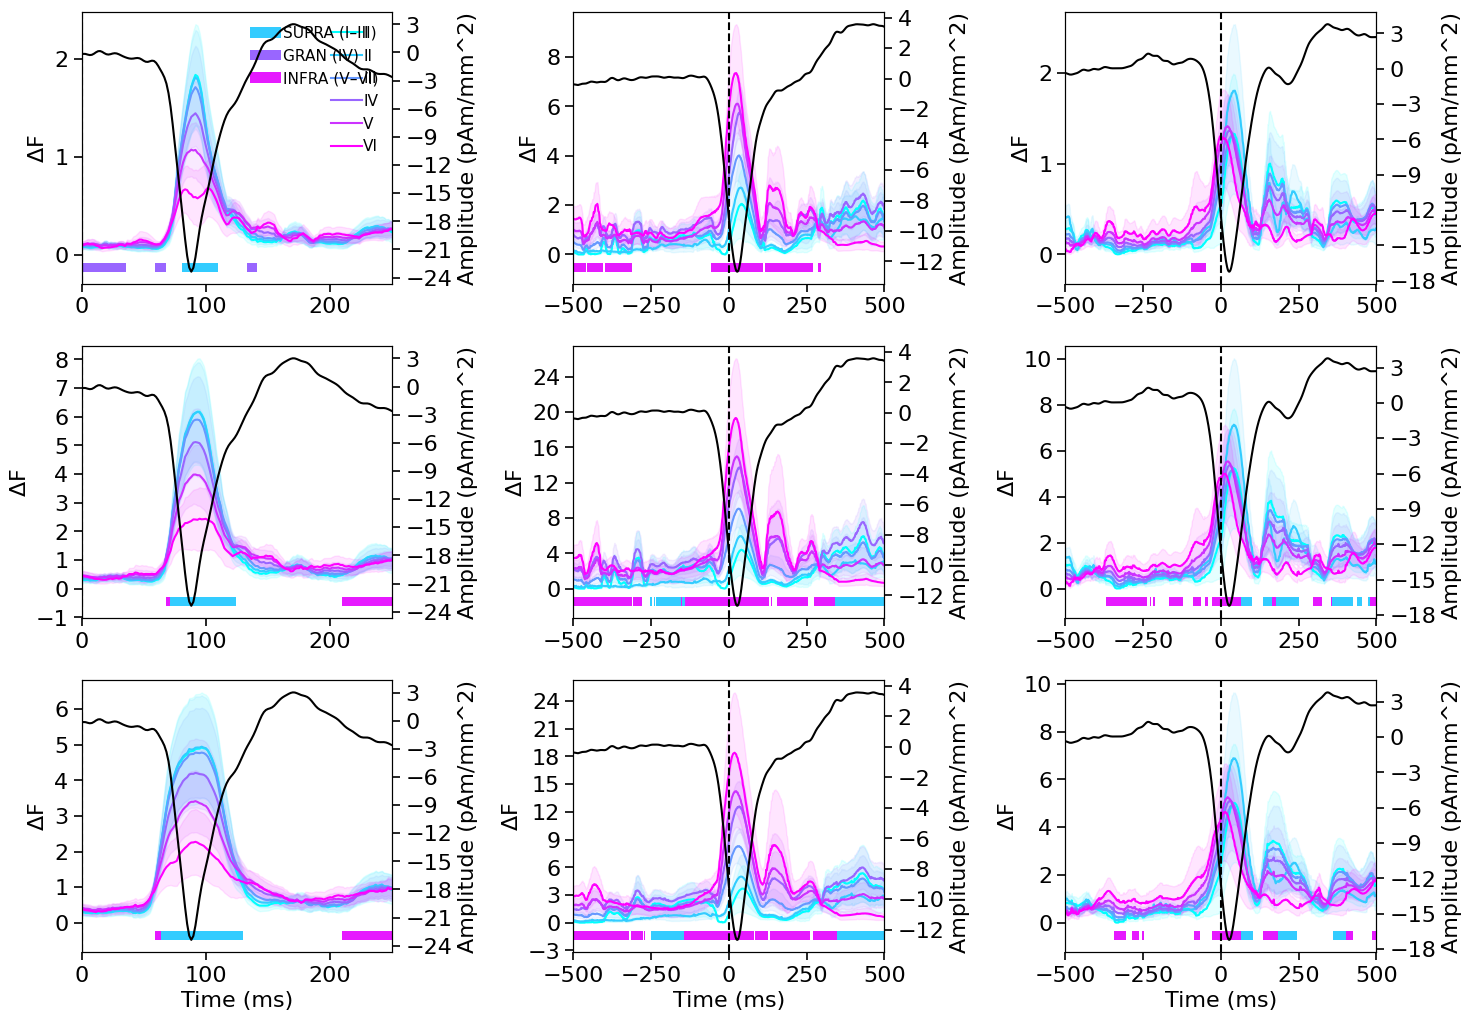

In [12]:
col_l = plt.cm.cool(np.linspace(0,1, num=6))
color_model_1 = col_l[0:3].mean(axis=0)
color_model_2 = col_l[3]
color_model_3 = col_l[4:6].mean(axis=0)

model_colors = {
    1: color_model_1,
    2: color_model_2,
    3: color_model_3
}

l_labels=['I','II','III','IV','V','VI']

stat_y_ratio=-.5/10
height_ratio=.5/14
plt.figure(figsize=(5*3,3.5*len(win_sizes)))

for w_idx, win_size in enumerate(win_sizes):
    ax=plt.subplot(len(win_sizes),3,w_idx*3+1)
    vba_fname=os.path.join(
        '/home/bonaiuto/visual_laminar/V1_ERF_F_diff', 
        f'ws{win_size}',
        'ps5',
        f'ERF_OverTime_F_contra_family_ws{win_size}_ps5.mat')
    print(vba_fname)
    vba_data = loadmat(vba_fname)
    bestModelOverTime = vba_data['bestModelOverTime'].squeeze()
    vba_time = vba_data['time'].squeeze()*1000
    
    m_prior_ts=np.mean(aligned_subjects_m_prior_ts['visual_erf'][win_size],axis=0)
    m_layer_F_diff=np.nanmean(aligned_subjects_m_layer_F_diff['visual_erf'][win_size],axis=0)
    se_layer_F_diff=np.nanstd(aligned_subjects_m_layer_F_diff['visual_erf'][win_size],axis=0)/np.sqrt(aligned_subjects_m_layer_F_diff['visual_erf'][win_size].shape[0])
    
    for i in range(6):
        ax.plot(woi_win_visual[0,:], m_layer_F_diff[i,:],label=l_labels[i],color=col_l[i])
        ax.fill_between(woi_win_visual[0,:], m_layer_F_diff[i,:]-se_layer_F_diff[i,:], m_layer_F_diff[i,:]+se_layer_F_diff[i,:], color=col_l[i], alpha=0.1)
    ax.axvline(x=0, color='k', linestyle='--')
    if w_idx==0:
        leg_layers=ax.legend(fontsize="x-small")
        ax.add_artist(leg_layers)

    
    height=np.diff(ax.get_ylim())
    y_model = stat_y_ratio*height#-0.5
    start_idx = 0

    for i in range(1, len(bestModelOverTime) + 1):
        if i == len(bestModelOverTime) or bestModelOverTime[i] != bestModelOverTime[start_idx]:
            model = bestModelOverTime[start_idx]
            if model != 0:
                t_start = vba_time[start_idx]
                t_end = vba_time[i - 1]
                ax.barh(
                    y_model,
                    width=t_end - t_start + np.median(np.diff(vba_time)),
                    left=t_start,
                    color=model_colors[model],
                    height=height*height_ratio
                )
            start_idx = i
    
    if w_idx==(len(win_sizes)-1):
        ax.set_xlabel('Time (ms)')
    ax.set_ylabel(r'$\Delta$F')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    
    if w_idx==0:
        model_handles = [
            Patch(facecolor=color_model_1, edgecolor='none', label='SUPRA (I–III)'),
            Patch(facecolor=color_model_2, edgecolor='none', label='GRAN (IV)'),
            Patch(facecolor=color_model_3, edgecolor='none', label='INFRA (V–VI)')
        ]

        ax.legend(
            handles=model_handles,
            frameon=False,
            fontsize="x-small"
        )


    ax2 = ax.twinx()
    ax2.plot(ts_time_visual[0,:], np.mean(aligned_subjects_m_prior_ts['visual_erf'][win_size],axis=0)*1000, 'k')
    ax2.set_ylabel('Amplitude (pAm/mm^2)')
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))

    ax.set_xlim([0, 250])
    ax2.set_xlim([0, 250])


        
    ax=plt.subplot(len(win_sizes),3,w_idx*3+2)
    
    if win_size==25:
        vba_data = loadmat(os.path.join('../output', f'mf_aligned_overtime_family_patch_size_5.0.mat'))
    else:
        vba_data = loadmat(os.path.join('../output', f'mf_aligned_overtime_family_win_size_{win_size}.mat'))
    bestModelOverTime = vba_data['bestModelOverTime'].squeeze()
    vba_time = vba_data['time'].squeeze()*1000
    
    m_prior_ts=np.mean(aligned_subjects_m_prior_ts['01_mf'][win_size],axis=0)
    m_layer_F_diff=np.nanmean(aligned_subjects_m_layer_F_diff['01_mf'][win_size],axis=0)
    se_layer_F_diff=np.nanstd(aligned_subjects_m_layer_F_diff['01_mf'][win_size],axis=0)/np.sqrt(aligned_subjects_m_layer_F_diff['01_mf'][win_size].shape[0])
    
    for i in range(6):
        ax.plot(woi_win_motor, m_layer_F_diff[i,:],label=l_labels[i],color=col_l[i])
        ax.fill_between(woi_win_motor, m_layer_F_diff[i,:]-se_layer_F_diff[i,:], m_layer_F_diff[i,:]+se_layer_F_diff[i,:], color=col_l[i], alpha=0.1)
    ax.axvline(x=0, color='k', linestyle='--')

    height=np.diff(ax.get_ylim())
    y_model = stat_y_ratio*height#-0.5
    start_idx = 0

    for i in range(1, len(bestModelOverTime) + 1):
        if i == len(bestModelOverTime) or bestModelOverTime[i] != bestModelOverTime[start_idx]:
            model = bestModelOverTime[start_idx]
            if model != 0:
                t_start = vba_time[start_idx]
                t_end = vba_time[i - 1]
                ax.barh(
                    y_model,
                    width=t_end - t_start + np.median(np.diff(vba_time)),
                    left=t_start,
                    color=model_colors[model],
                    height=height*height_ratio
                )
            start_idx = i

    if w_idx==(len(win_sizes)-1):
        ax.set_xlabel('Time (ms)')
    ax.set_ylabel(r'$\Delta$F')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax2=ax.twinx()
    ax2.plot(ts_time_motor,m_prior_ts,'k')
    ax2.set_ylabel('Amplitude (pAm/mm^2)')
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlim(time_lims)
    
    
    
    
    ax=plt.subplot(len(win_sizes),3,w_idx*3+3)
    
    if win_size==25:
        vba_data = loadmat(os.path.join('../output', f'mefI_aligned_overtime_family_patch_size_5.0.mat'))
    else:
        vba_data = loadmat(os.path.join('../output', f'mefI_aligned_overtime_family_win_size_{win_size}.mat'))
    bestModelOverTime = vba_data['bestModelOverTime'].squeeze()
    vba_time = vba_data['time'].squeeze()*1000

    m_prior_ts=np.mean(aligned_subjects_m_prior_ts['02_mefI'][win_size],axis=0)
    m_layer_F_diff=np.nanmean(aligned_subjects_m_layer_F_diff['02_mefI'][win_size],axis=0)
    se_layer_F_diff=np.nanstd(aligned_subjects_m_layer_F_diff['02_mefI'][win_size],axis=0)/np.sqrt(aligned_subjects_m_layer_F_diff['02_mefI'][win_size].shape[0])
    
    for i in range(6):
        ax.plot(woi_win_motor, m_layer_F_diff[i,:],label=l_labels[i],color=col_l[i])
        ax.fill_between(woi_win_motor, m_layer_F_diff[i,:]-se_layer_F_diff[i,:], m_layer_F_diff[i,:]+se_layer_F_diff[i,:], color=col_l[i], alpha=0.1)
    ax.axvline(x=0, color='k', linestyle='--')

    
    height=np.diff(ax.get_ylim())
    y_model = stat_y_ratio*height#-0.5
    start_idx = 0

    for i in range(1, len(bestModelOverTime) + 1):
        if i == len(bestModelOverTime) or bestModelOverTime[i] != bestModelOverTime[start_idx]:
            model = bestModelOverTime[start_idx]
            if model != 0:
                t_start = vba_time[start_idx]
                t_end = vba_time[i - 1]
                ax.barh(
                    y_model,
                    width=t_end - t_start + np.median(np.diff(vba_time)),
                    left=t_start,
                    color=model_colors[model],
                    height=height*height_ratio
                )
            start_idx = i

    if w_idx==(len(win_sizes)-1):
        ax.set_xlabel('Time (ms)')
    ax.set_ylabel(r'$\Delta$F')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax2=ax.twinx()
    ax2.plot(ts_time_motor,m_prior_ts,'k')
    ax2.set_ylabel('Amplitude (pAm/mm^2)')
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlim(time_lims)
    
plt.tight_layout()

plt.savefig('./figure_S19_erf_win_size.pdf')